In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
include("../scripts/TesselationCore.jl")
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end


  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

import .TesselationCore


In [3]:
abstract type BVHTree end

struct BVHLeaf <: BVHTree
    data::Vector{Int}
end

struct BVHNode <: BVHTree
    depth::Int
    leftChild::BVHTree 
    rightChild::BVHTree
end


struct BVH
    tree::BVHTree
    bbox::Matrix{Float64}   
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix)
    indices = 1:size(boxes,3)
    return generateBVHTree(boxes,depth,limBox,indices)
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix, indices)
    
    if depth == 0 || size(boxes,3) < 2 
        if depth!=0
            println("Nontrivial leaf $depth") #REMOVE BEFORE PROD
        end
        return BVHLeaf(indices)
    end
    
    ax = depth%3 + 1

    mins = boxes[ax,1,indices]
    maxs = boxes[ax,2,indices]
    
    line = (limBox[ax,2]+limBox[ax,1])/2 

    leftIDs = indices[mins .≤ line]
    rightIDs = indices[maxs .≥ line]

    leftBox = copy(limBox)
    leftBox[ax,2] = line
    
    rightBox = copy(limBox)
    rightBox[ax,1] = line

    return BVHNode(depth,
    generateBVHTree(boxes,depth-1,leftBox,leftIDs), 
    generateBVHTree(boxes,depth-1,rightBox,rightIDs))
end


function BVH(data::Vector,depth::Int)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])
    tree = generateBVHTree(boxes,depth,box)
    
    return BVH(tree,box)
end

function BVH(data::Vector,depth::Int,box::Matrix)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    tree = generateBVHTree(boxes,depth,box)
    return BVH(tree,box)
end

function cornerSimplexMatr(simplex)
    return hcat(minimum(simplex,dims=1)',maximum(simplex,dims=1)') 
end




cornerSimplexMatr (generic function with 1 method)

In [74]:
function recursiveSearch(point,leaf::BVHLeaf,bbox::Matrix) 
    return leaf.data 
end

function recursiveSearch(point,tree::BVHNode,bbox::Matrix)
    ax = tree.depth%3 + 1

    newBox = copy(bbox)

    line = (bbox[ax,2]+bbox[ax,1])/2
    if point[ax]<line
        newBox[ax,2] = line
        return recursiveSearch(point,tree.leftChild,newBox)
    end
    newBox[ax,1] = line
    return recursiveSearch(point,tree.rightChild,newBox)
end


function findSimplex(point,simplices, bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)
    
    simplNeighborhood = simplices[indices]

    idx = earlyStopSearch(point,simplNeighborhood)

    return simplNeighborhood[idx]
end

function findID(point,simplices, bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)
    
    simplNeighborhood = simplices[indices]

    idx = earlyStopSearch(point,simplNeighborhood)

   if idx == nothing
        return nothing
   end

    return indices[idx]
end

function findID(point,simplices::Matrix, bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)
    
    simplNeighborhood = simplices[indices,:]

    idx = earlyStopSearch(point,simplNeighborhood)

    if idx == nothing
        return nothing
    end

    return indices[idx]
end


function earlyStopSearch(p::Vector{Float64}, simplices::Vector)
    for (i, s) in pairs(simplices)
        if intersection3D(p, s)
            return i
        end
    end
end

function earlyStopSearch(p::Vector{Float64}, simplices::Matrix)
    for (i, s) in pairs(eachrow(simplices))
        if intersection3D(p, s)
            return i
        end
    end
end


@inline function intersection3D(p::SVector{3, Float64}, simplex::SMatrix{4, 3, Float64})
    @inbounds begin
        v1, v2, v3, v4 = simplex[1, :], simplex[2, :], simplex[3, :], simplex[4, :]
        a = v2 - v1 
        b = v3 - v1 # distances from v1 to each vertex and p
        c = v4 - v1
        r = p - v1

        detA = dot(a, cross(b, c))  # Cramer's rule to make things faster
        x1 = dot(r, cross(b, c)) / detA
        x2 = dot(r, cross(c, a)) / detA
        x3 = dot(r, cross(a, b)) / detA
    end

    s = x1 + x2 + x3
    return (x1 >= 0) & (x2 >= 0) & (x3 >= 0) & (s <= 1)
end

@inline function intersection3D(point, simplex)
    @inbounds begin
        p = SVector{3,Float64}(point)
        v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]
        a = v2 - v1 
        b = v3 - v1 # distances from v1 to each vertex and p
        c = v4 - v1
        r = p - v1

        detA = dot(a, cross(b, c))  # Cramer's rule to make things faster
        x1 = dot(r, cross(b, c)) / detA
        x2 = dot(r, cross(c, a)) / detA
        x3 = dot(r, cross(a, b)) / detA
    end

    s = x1 + x2 + x3
    return (x1 >= 0) & (x2 >= 0) & (x3 >= 0) & (s <= 1)
end

function intersection3D(p::Vector{Float64}, simplex::Matrix)
    sP = SVector{3}(p)
    sSimp = SMatrix{4,3}(simplex)
    return intersection3D(sP, sSimp)
end



intersection3D (generic function with 4 methods)

In [5]:
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:50]

50-element Vector{SVector{3, Float64}}:
 [0.054323860047034156, 0.7637069876577084, 0.9052820488945904]
 [0.7462116589960853, 0.9200752773219354, 0.45074435192082685]
 [0.57660371850866, 0.86340127690384, 0.6767469726142826]
 [0.762514579620574, 0.3081061819684098, 0.5132187492729148]
 [0.40136542903966166, 0.8240330815572826, 0.8059732401557658]
 [0.002487450711168626, 0.9646477165261512, 0.0032586913127558015]
 [0.5912916360085232, 0.7469562660231053, 0.34011642867756064]
 [0.008790067822355252, 0.49417329982831837, 0.527489960092204]
 [0.4395488301710656, 0.24656365419925697, 0.8196386969121711]
 [0.9376978491526785, 0.4774939356311527, 0.8834430546956674]
 ⋮
 [0.6798389080196727, 0.7345903545770115, 0.4515926281689374]
 [0.8845620078990578, 0.8948279906988235, 0.3999934567520166]
 [0.29365013518457683, 0.6990984611227191, 0.29516412325010133]
 [0.5876425221697712, 0.3204007754159435, 0.7091463977639366]
 [0.11959645571272559, 0.9851095714288719, 0.6451445500383182]
 [0.695268237342

In [6]:
function standardEstimator(points, weights)

    coords, tets = TesselationCore.tesselate(points)
    tes = TesselationCore.Triangulation3D(points,tets',weights)

#TODO do this smarter later
    simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])

    bvh = BVH(simplices,9)

    return bvh,tes,tets
end

bvh,tesselation,tetrahedra = standardEstimator(points3d,ones(50))

SVector{3, Float64}[[0.6041880365397029, 0.32609325519633114, 0.5918559892758055], [0.9376978491526785, 0.4774939356311527, 0.8834430546956674], [0.57660371850866, 0.86340127690384, 0.6767469726142826], [0.5923986869299189, 0.8209777503801297, 0.19562501155849565], [0.25242204830551873, 0.7575986842566179, 0.6320861655113461], [0.5876425221697712, 0.3204007754159435, 0.7091463977639366], [0.695268237342046, 0.49788898816685934, 0.9054459397615447], [0.3646042169875088, 0.10030003780209407, 0.15475857324068742], [0.03249047593907406, 0.010142448080726951, 0.2577806722854341], [0.5923986869299189, 0.8209777503801297, 0.19562501155849565], [0.15511922010611334, 0.3613584755194389, 0.8712761248466594], [0.03249047593907406, 0.010142448080726951, 0.2577806722854341], [0.002487450711168626, 0.9646477165261512, 0.0032586913127558015], [0.3646042169875088, 0.10030003780209407, 0.15475857324068742], [0.12099844395444981, 0.39680767759566016, 0.9968205810291825], [0.25242204830551873, 0.75759868

(BVH(BVHNode(9, BVHNode(8, BVHNode(7, BVHNode(6, BVHNode(5, BVHNode(4, BVHNode(3, BVHNode(2, BVHNode(1, BVHLeaf([8, 9, 12, 17, 18, 51, 78, 79, 159]), BVHLeaf([8, 9, 12, 17, 18, 20, 51, 78, 79])), BVHNode(1, BVHLeaf([8, 9, 12, 51, 78, 79, 129, 140, 159]), BVHLeaf([8, 9, 12, 20, 51, 78, 79, 129]))), BVHNode(2, BVHNode(1, BVHLeaf([8, 9, 12, 17, 18, 41, 51, 78, 79, 159]), BVHLeaf([8, 9, 12, 17, 18, 19, 20, 25, 41, 42, 51, 78, 79, 186, 224, 226])), BVHNode(1, BVHLeaf([8, 9, 12, 51, 78, 79, 129, 140, 159]), BVHLeaf([8, 9, 12, 19, 20, 25, 42, 51, 78, 79, 129, 224, 226])))), BVHNode(3, BVHNode(2, BVHNode(1, BVHLeaf([9, 12, 17, 18, 20, 51, 79]), BVHLeaf([9, 12, 13, 17, 18, 20, 38, 51, 65, 66, 79])), BVHNode(1, BVHLeaf([9, 12, 20, 51, 79]), BVHLeaf([9, 12, 13, 20, 38, 51, 65, 66, 79]))), BVHNode(2, BVHNode(1, BVHLeaf([9, 12, 17, 18, 19, 20, 25, 41, 42, 51, 79, 186, 224, 226]), BVHLeaf([9, 12, 13, 17, 18, 19, 20, 25, 27, 28, 41, 42, 51, 65, 66, 79, 186, 224, 226])), BVHNode(1, BVHLeaf([9, 12, 19,

In [80]:
function DTFE(point,bvh,tetrahedra,tesselation)

    coords = tesselation.points
    simplices = coords[tetrahedra]

    i = findID(point,simplices,bvh)
    if i == nothing
        return 0
    end

    final = simplices[i]

    tet = tetrahedra[i,:]
    simp = coords[tet]
    rhos = tesselation.ρStar[tet]

    delRho=invertClassic(rhos,simp)

    interpolation = rhos[1] + dot((point - simp[1]),delRho)

    return interpolation
end

function invertClassic(rhos,simplex) 
    r = rhos[2:end] .- rhos[1]

    v1, v2, v3, v4 = simplex[1], simplex[2], simplex[3], simplex[4]

    a = v2 - v1 
    b = v3 - v1 
    c = v4 - v1

    mat = SMatrix{3,3}([a;b;c])
    
    return inv(mat)*r
end

point = rand(3)

3-element Vector{Float64}:
 0.07222842696223675
 0.9701970471091845
 0.6478071478676437

In [76]:
DTFE(point,bvh,tetrahedra,tesselation)

35626.851375162136

In [92]:
xs = 0.01:0.01:1
ys = 0.01:0.01:1

dens = zeros(100,100)

100×100 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱            ⋮                   
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

In [96]:
for (i,x) in pairs(xs)
    for (j,y) in pairs(ys)
        dens[i,j] = DTFE([x,y,0.5],bvh,tetrahedra,tesselation)

    end
end

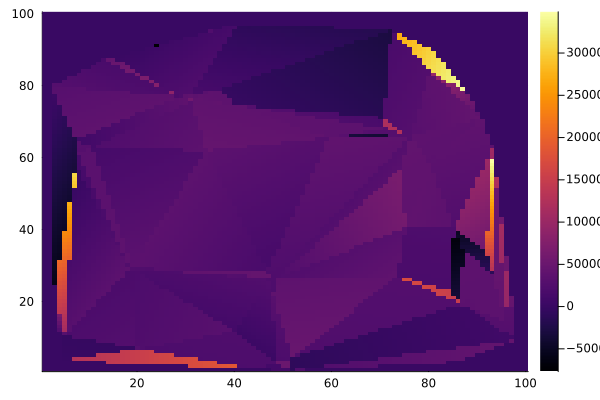

In [97]:
heatmap(dens)